## Does structural Connectome make sense at all?

- 1. structural–functional correspondence analysis
- 2. Long range connections? e.g. Default Mode Network ? 
- 3. Degree Centrality ?

references
- Mapping the Structural Core of Human Cerebral Cortex
- Predicting human resting-state functional connectivity from structural connectivity; Honey 2009
exponentially distributed and spanned several orders of magnitude. Reasoning that interregional physiological efficacies would not span such a large range, we resampled the fiber strengths into a Gaussian distribution 


In [5]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')
plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.parcel')

subList = [f'{i:02d}' for i in range(1, 67)]
sub_array= np.array([int(i) for i in subList]) 

## 1. Structural–functional correspondence analysis

is structural connectome predictive of functional connectome in individuals?
test: higher correlation for same sub than across any subs --> noo..... :(

In [2]:
import numpy as np

def resample_to_gaussian(connectome, mean=0.5, std=0.1):
    """
    Resample the nonzero elements of a structural connectome (DTI-based) 
    to follow a Gaussian distribution with specified mean and std.
    
    Parameters:
        connectome (np.ndarray): 2D square matrix of fiber strengths.
        mean (float): Mean of the resampled Gaussian distribution.
        std (float): Standard deviation of the resampled Gaussian distribution.
    
    Returns:
        np.ndarray: Connectome with resampled fiber strengths.
    """
    conn = connectome.copy()
    # Find the indices of the nonzero entries (assuming symmetry isn't enforced yet)
    nonzero_indices = np.nonzero(conn)
    values = conn[nonzero_indices]

    # Sort original values and generate sorted Gaussian samples
    sorted_indices = np.argsort(values)
    sorted_values = values[sorted_indices]

    # Generate sorted Gaussian random values
    gaussian_samples = np.random.normal(loc=0.0, scale=1.0, size=len(sorted_values))
    gaussian_samples_sorted = np.sort(gaussian_samples)

    # Replace each original value with a sorted Gaussian sample
    resampled_values = np.empty_like(values)
    resampled_values[sorted_indices] = gaussian_samples_sorted

    # Rescale to desired mean and std
    resampled_values = mean + std * resampled_values

    # Place back into the matrix
    resampled_conn = np.zeros_like(conn)
    resampled_conn[nonzero_indices] = resampled_values

    return resampled_conn


#### One subject

In [3]:
atlas = 'Glasser_hemiUnique' #'AAL3_amended' # 
sub = subList[2]

connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
connectome = pd.read_csv(connectome_file,header=None)
mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
C = np.array(connectome)
cm_s = (C + C.T) * mu_factor

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.parcel')
confspec = '32Pscrub3BPfilter'
cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
cm_f = np.load(cm_file)

# Z-score the connectome
cm_s_z = (cm_s - np.mean(cm_s)) / np.std(cm_s)
cm_f_z = (cm_f - np.mean(cm_f)) / np.std(cm_f)


In [4]:
cm_s_gaussian = resample_to_gaussian(cm_s, mean=0.5, std=0.1)
cm_s_z = cm_s_gaussian #(cm_s_gaussian - np.mean(cm_s)) / np.std(cm_s)


[(-3.0, 6.0), (0.0, 5000.0)]

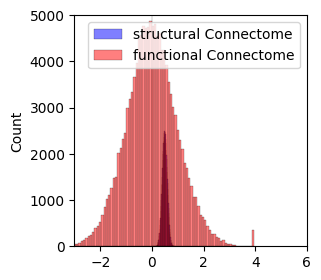

In [24]:
import seaborn as sns
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(cm_s_z.flatten(), bins=100, color='blue', label='structural Connectome',ax=ax, alpha=0.5)
sns.histplot(cm_f_z.flatten(), bins=100, color='red', label='functional Connectome', ax=ax, alpha=0.5)
plt.legend()
ax.set(xlim=(-3, 6), ylim=(0, 5000))

In [25]:
from scipy.stats import pearsonr

corr, pval = pearsonr(cm_s_z.flatten(), cm_f_z.flatten())
print(f'Pearson correlation: {corr:.3f}, p-value: {pval:.3e}')

mask = cm_s_z.flatten() > 0 
corr_masked, pval_masked = pearsonr(cm_s_z.flatten()[mask], cm_f_z.flatten()[mask])
print(f'Masked Pearson correlation: {corr_masked:.3f}, p-value: {pval_masked:.3e}')

# absolute values for functional connectome + masked
cm_f_abs = np.abs(cm_f_z)
corr_abs, pval_abs = pearsonr(cm_s_z.flatten()[mask], cm_f_abs.flatten()[mask])
print(f'Absolute functional Pearson correlation: {corr_abs:.3f}, p-value: {pval_abs:.3e}')

# only psotive values for functional connectome + masked
cm_f_pos = np.maximum(cm_f_z, 0)
corr_pos, pval_pos = pearsonr(cm_s_z.flatten()[mask], cm_f_pos.flatten()[mask])
print(f'Positive functional Pearson correlation: {corr_pos:.3f}, p-value: {pval_pos:.3e}')


Pearson correlation: 0.156, p-value: 0.000e+00
Masked Pearson correlation: 0.285, p-value: 0.000e+00
Absolute functional Pearson correlation: 0.217, p-value: 0.000e+00
Positive functional Pearson correlation: 0.336, p-value: 0.000e+00


#### Across subjects

In [ ]:
# load in all struct & func connectomes
atlas = 'Glasser_hemiUnique' #'AAL3_amended' # 
confspec = '36Pscrub3BPfilter'

cmSs = []
cmFs = []
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file,header=None)
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
    C = np.array(connectome)
    cm_s = (C + C.T) * mu_factor
    cmSs.append((cm_s - np.mean(cm_s)) / np.std(cm_s))

    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
    cm_f = np.load(cm_file)
    cmFs.append((cm_f - np.mean(cm_f)) / np.std(cm_f))

# Across subject correlations between structural and functional connectomes
cm_s_all = np.array(cmSs)
cm_f_all = np.array(cmFs)

import seaborn as sns
from matplotlib import pyplot as plt

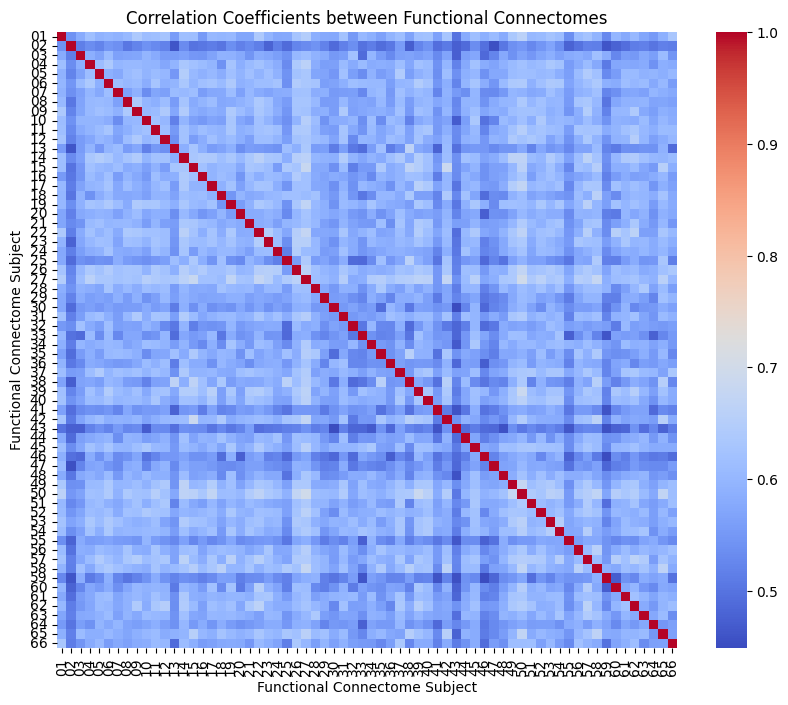

In [ ]:
# Calculate correlation coefficients between functional connectomes
corcoefs_mat = np.zeros((len(subList), len(subList)))
for i in range(len(subList)):
    for j in range(len(subList)):
        corcoefs_mat[i, j] = np.corrcoef(cm_f_all[i].flatten(), cm_f_all[j].flatten())[0,1]
plt.figure(figsize=(10, 8))
sns.heatmap(corcoefs_mat, fmt=".2f", cmap='coolwarm', xticklabels=subList, yticklabels=subList)
plt.title('Correlation Coefficients between Functional Connectomes')
plt.xlabel('Functional Connectome Subject')
plt.ylabel('Functional Connectome Subject')
plt.show()

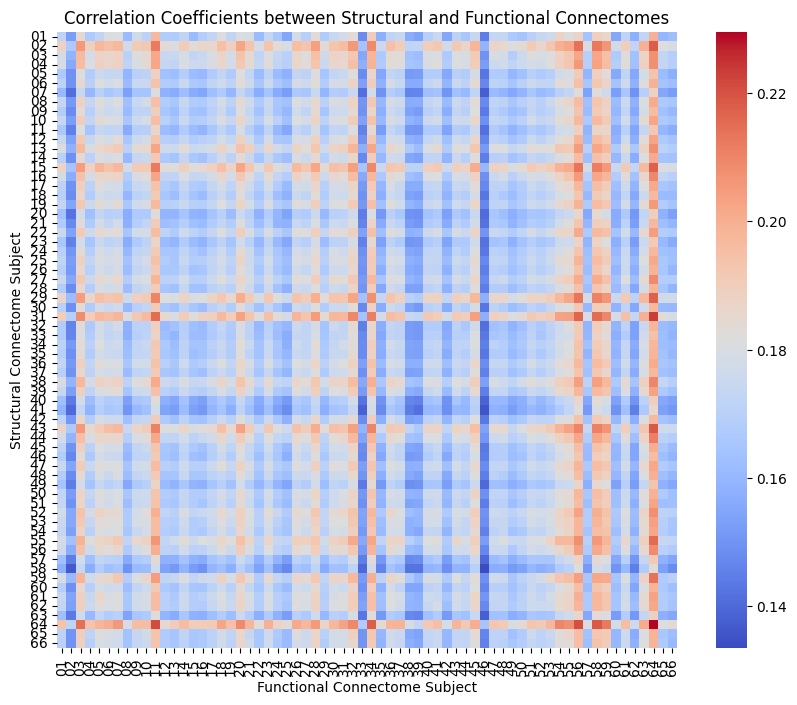

In [ ]:
# Calculate correlation coefficients between structural and functional connectomes

corcoefs_mat = np.zeros((len(subList), len(subList)))
for i in range(len(subList)):
    for j in range(len(subList)):
        corcoefs_mat[i, j] = np.corrcoef(cm_s_all[i].flatten(), cm_f_all[j].flatten())[0,1]

plt.figure(figsize=(10, 8))
sns.heatmap(corcoefs_mat, fmt=".2f", cmap='coolwarm', xticklabels=subList, yticklabels=subList)
plt.title('Correlation Coefficients between Structural and Functional Connectomes')
plt.xlabel('Functional Connectome Subject')
plt.ylabel('Structural Connectome Subject')
plt.show()

In [30]:
# correlation distribution with struct & func connectome from same subject
masked = True
only_positiveFC = True
resample_gaussian = False  # whether to resample the structural connectome to a Gaussian distribution

c_coeffs = []
for i, subA in enumerate(subList):
    cm_s_z = cmSs[i]
    cm_f_z = cmFs[i] 
    if resample_to_gaussian:
        cm_s_z = resample_to_gaussian(cm_s_z, mean=0.5, std=0.1)   
    mask = cm_s_z.flatten() > 0 if masked else np.ones_like(cm_s_z.flatten(), dtype=bool)
    if only_positiveFC:
        #cm_f_z[cm_f_z < 0]  = 0 # only positive values for functional connectome
        cm_f_z = np.maximum(cm_f_z, 0)
    corr_masked, pval_masked = pearsonr(cm_s_z.flatten()[mask], cm_f_z.flatten()[mask])
    c_coeffs.append(corr_masked)


In [31]:
# correlation distribution with struct & func connectome from different subjects

c_coeffs_diff = []
for i, subA in enumerate(subList):
    for j, subB in enumerate(subList[i+1:]):
        #if i != j:
            cm_s_z = cmSs[i]
            cm_f_z = cmFs[j]    
            if resample_to_gaussian:
                cm_s_z = resample_to_gaussian(cm_s_z, mean=0.5, std=0.1)   
            mask = cm_s_z.flatten() > 0 if masked else np.ones_like(cm_s_z.flatten(), dtype=bool)
            if only_positiveFC:
                #cm_f_z[cm_f_z < 0]  = 0
                cm_f_z = np.maximum(cm_f_z, 0)
            corr_masked, pval_masked = pearsonr(cm_s_z.flatten()[mask], cm_f_z.flatten()[mask])
            c_coeffs_diff.append(corr_masked)



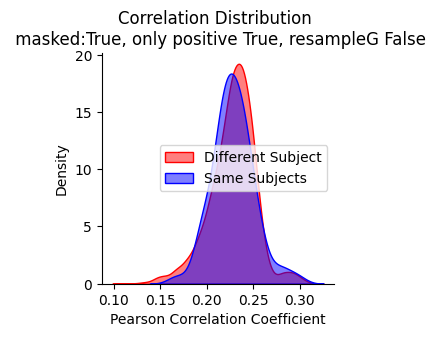

In [32]:
fig, ax = plt.subplots(figsize=(3,3))
sns.kdeplot(c_coeffs_diff, color='red',ax=ax, alpha=0.5, fill=True, label='Different Subject')
sns.kdeplot(c_coeffs, color='blue', ax=ax, alpha=0.5, fill=True, label='Same Subjects')
plt.legend()#
ax.set(title=f'Correlation Distribution \n masked:{masked}, only positive {only_positiveFC}, resampleG {resample_gaussian}'.format(masked=masked),
       xlabel='Pearson Correlation Coefficient', ylabel='Density')
sns.despine()

## Correlations with mean connectivity


In [43]:
cmF_mean = np.mean(cmFs, axis=0)
cmS_mean = np.mean(cmSs, axis=0)

print(np.shape(cmF_mean), np.shape(cmS_mean))

(360, 360) (360, 360)


In [ ]:
# for mean FC: argtan transform individual connectomes, average and then transform back
av_cm = np.zeros_like(cmF_mean)
for sub in subList:
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
    cm_f = np.load(cm_file)
    av_cm += np.arctan(cm_f)

av_cm = av_cm / len(subList)
av_cm_transf = np.tan(av_cm) 



In [80]:
cmF_mean = av_cm_transf

In [52]:
corr, pval = pearsonr(cmF_mean.flatten(), cmS_mean.flatten())
print(f'Pearson correlation: {corr:.3f}, p-value: {pval:.3e}')

mask = cmS_mean.flatten() > 0 
corr_masked, pval_masked = pearsonr(cmS_mean.flatten()[mask], cmF_mean.flatten()[mask])
print(f'Masked Pearson correlation: {corr_masked:.3f}, p-value: {pval_masked:.3e}')

# only psotive values for functional connectome + masked || not needed, after averaging no negative functional corrrelations anymore
#mF_mean_pos = np.maximum(cmF_mean, 0)
#corr_pos, pval_pos = pearsonr(cmS_mean.flatten()[mask], cmF_mean_pos.flatten()[mask])
#print(f'Positive functional Pearson correlation: {corr_pos:.3f}, p-value: {pval_pos:.3e}')

# resample the structural connectome to a Gaussian distribution
cmS_mean_gaussian = resample_to_gaussian(cmS_mean, mean=0, std=1) # mean=0.5, std=0.1)# 
corr_gaussian, pval_gaussian = pearsonr(cmS_mean_gaussian.flatten()[mask], cmF_mean.flatten()[mask])
print(f'Gaussian resampled structural Pearson correlation: {corr_gaussian:.3f}, p-value: {pval_gaussian:.3e}')

Pearson correlation: 0.232, p-value: 0.000e+00
Masked Pearson correlation: 0.331, p-value: 1.139e-258
Gaussian resampled structural Pearson correlation: 0.457, p-value: 0.000e+00


## Distance (euclidean - by coordinates of parcels)

In [8]:
# Fiber Distance and Euclidean Distance.

# get distances between every parcel from coords information (generated below)
# coords.shape # 360, 3

from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance  
distances = squareform(pdist(coords, metric='euclidean'))  # Euclidean distance
fiber_distances = squareform(pdist(coords, metric='sqeuclidean'))  # Squared Euclidean distance


In [ ]:
distances_1 = 1/distances

/tmp/ipykernel_930653/596950192.py:1: RuntimeWarning: divide by zero encountered in divide
  distances = 1/distances


In [77]:
# Fix infinity values in distances matrix
# The diagonal elements (distance from parcel to itself) are 0, so 1/0 = inf
# We need to handle these properly

# Option 1: Set diagonal to 0 (no self-connections in distance analysis)
np.fill_diagonal(distances, 0)

# Option 2: Alternative approach - use inverse distance but handle zeros
# distances_fixed = np.where(distances == np.inf, 0, distances)

print(f"Number of infinite values: {np.sum(np.isinf(distances))}")
print(f"Number of NaN values: {np.sum(np.isnan(distances))}")
print(f"Distance matrix range: {np.min(distances[distances > 0]):.6f} to {np.max(distances[np.isfinite(distances)]):.6f}")

Number of infinite values: 0
Number of NaN values: 0
Distance matrix range: 0.006124 to 0.385002


Distance - Structural Pearson correlation: 0.638, p-value: 0.000e+00
Distance - Functional Pearson correlation: 0.386, p-value: 0.000e+00


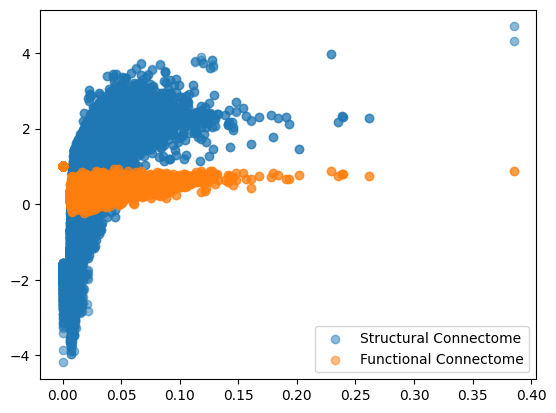

In [81]:
plt.scatter(distances.flatten(), cmS_mean_gaussian.flatten(), alpha=0.5, label='Structural Connectome')
plt.scatter(distances.flatten(), cmF_mean.flatten(), alpha=0.5, label='Functional Connectome')
plt.legend()

# Create mask to exclude diagonal elements and any remaining problematic values
mask = ~np.eye(distances.shape[0], dtype=bool)  # Exclude diagonal
dist_flat = distances[mask]
cmS_flat = cmS_mean_gaussian[mask] 
cmF_flat = cmF_mean[mask]

# Additional check for finite values
finite_mask = np.isfinite(dist_flat) & np.isfinite(cmS_flat) & np.isfinite(cmF_flat)
dist_clean = dist_flat[finite_mask]
cmS_clean = cmS_flat[finite_mask]
cmF_clean = cmF_flat[finite_mask]

# correlation between distances and connectomes
corr_dist_s, pval_dist_s = pearsonr(dist_clean, cmS_clean)
print(f'Distance - Structural Pearson correlation: {corr_dist_s:.3f}, p-value: {pval_dist_s:.3e}')
corr_dist_f, pval_dist_f = pearsonr(dist_clean, cmF_clean)
print(f'Distance - Functional Pearson correlation: {corr_dist_f:.3f}, p-value: {pval_dist_f:.3e}')

Distance - Functional Residuals Pearson correlation: 0.000, p-value: 1.000e+00


Text(0.5, 1.0, 'Distance vs Functional Residuals')

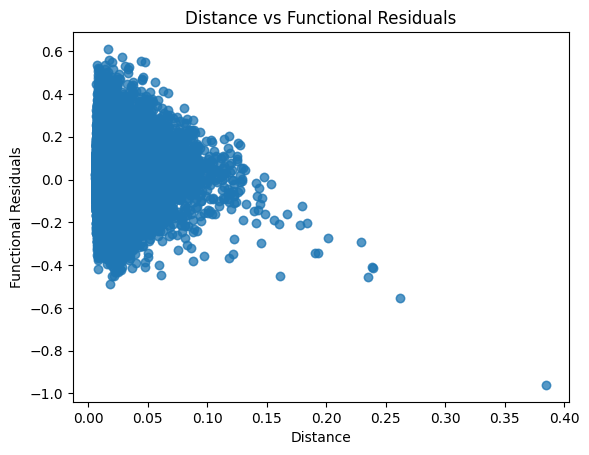

In [79]:
# can the residuals variance after regressing out the distance from FC be explaiend by SC?
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(dist_clean.reshape(-1, 1), cmF_clean)   
cmF_residuals = cmF_clean - reg.predict(dist_clean.reshape(-1, 1))
# correlation between distances and residuals
corr_residuals, pval_residuals = pearsonr(dist_clean, cmF_residuals)
print(f'Distance - Functional Residuals Pearson correlation: {corr_residuals:.3f}, p-value: {pval_residuals:.3e}')
plt.scatter(dist_clean, cmF_residuals, alpha=0.5)
plt.xlabel('Distance')
plt.ylabel('Functional Residuals')
plt.title('Distance vs Functional Residuals')

### control for spatial autocorrelation?


In [ ]:

from brainspace.null_models import SpinPermutations



## 2. Long range connections?




In [111]:
atlas ='AAL3_amended' # 'Glasser_hemiUnique' #
cmSs = []
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file,header=None)
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
    C = np.array(connectome)
    cm_s = (C + C.T) * mu_factor
    cmSs.append(cm_s)        #(cm_s - np.mean(cm_s)) / np.std(cm_s))

mean_cmS = np.mean(cmSs, axis=0)
print(np.shape(mean_cmS))

(170, 170)


In [5]:
atlas_nii = nib.load(op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk', 
            'GlasserParcellationAtlas_MNI_hemiUnique/HCP-MMP1_on_MNI152_ICBM2009a_nlin_hemi-unique.nii.gz'))
atlas_data = atlas_nii.get_fdata() 
affine = atlas_nii.affine 

In [108]:
# load AAL3 atlas
atlas_nii = nib.load(op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk', 
    'AAL3/amended/AAL3_amended.nii.gz'))
atlas_data = atlas_nii.get_fdata() 
affine = atlas_nii.affine 

In [6]:
import numpy as np
from scipy.ndimage import center_of_mass

# Get unique parcel labels (excluding 0, which is usually background)
labels = np.unique(atlas_data)
labels = labels[labels != 0]

coords = []

for label in labels:
    # Binary mask for the parcel
    mask = atlas_data == label

    # Center of mass in voxel space
    com_voxel = center_of_mass(mask)

    # Convert voxel indices to MNI space using affine
    com_mni = nib.affines.apply_affine(affine, com_voxel)
    coords.append(com_mni)

coords = np.array(coords)


In [7]:
labels.astype(int)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [ ]:
# for AAL3_amended, there are some parcels that are not in the connectome, so we need to filter them out
mean_cmS_fil = mean_cmS[labels.astype(int)-1,:][:,labels.astype(int)-1]
print(np.shape(mean_cmS_fil))

(162, 162)


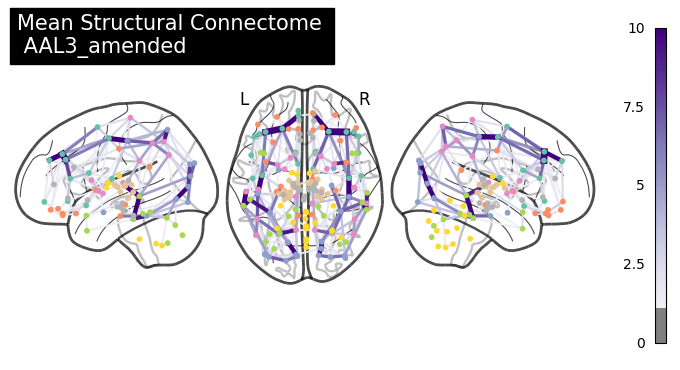

In [125]:
# adjacency_matrix - thresholded?

from nilearn.plotting import plot_connectome

plot_connectome(mean_cmS_fil, coords,
                edge_threshold='98%',
                title=f'Mean Structural Connectome \n {atlas} ',
                display_mode='lzr',
                colorbar=True,
                node_size=10,
                edge_cmap = 'Purples',
                edge_vmin=0, edge_vmax=10,
)


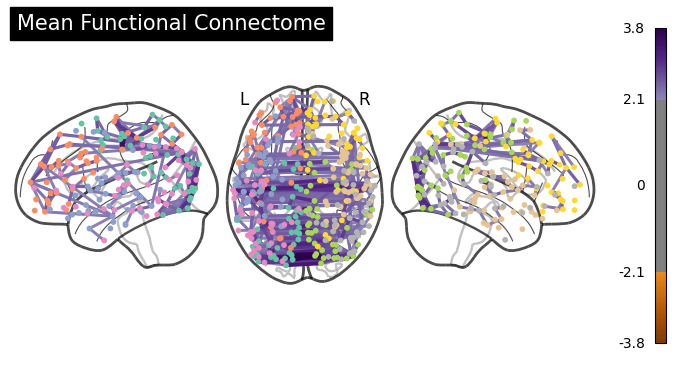

In [105]:
# mean functional connectome
mean_cmF = np.mean(cmFs, axis=0)
plot_connectome(mean_cmF, coords,
                edge_threshold='99%',
                title='Mean Functional Connectome',
                display_mode='lzr',
                colorbar=True,
                node_size=10,
                edge_cmap = 'PuOr',
                #edge_vmin=0, edge_vmax=2,
)

## 3. Degree Centrality ?
Mapping the Structural Core of Human Cerebral Cortex
The structural core contains brain regions that form the posterior components of the human default network. Looking both within and outside of core regions, we observed a substantial correspondence between structural connectivity and resting-state functional connectivity measured in the same participants.